In [1]:
# polynomial regression

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.metrics import  r2_score

from sklearn.pipeline import Pipeline

In [3]:
X = 6 * np.random.rand(200,1) - 3
y = 0.8 * X**2 + 0.9 * X + 2+ np.random.randn(200,1)


In [4]:
import matplotlib.pyplot as plt

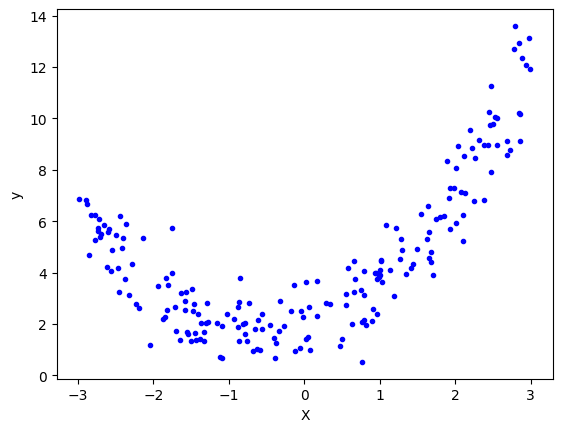

In [5]:
plt.plot(X,y,"b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

In [12]:
X_train.shape

(160, 1)

In [13]:
y_train.shape

(160, 1)

In [14]:
lr = LinearRegression()

In [15]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.05955900102737821

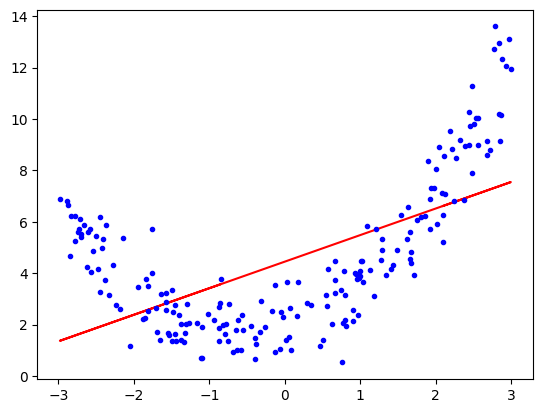

In [17]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X,y,"b.")
plt.show()

In [20]:
sgd = SGDRegressor(max_iter=100,learning_rate='constant')

In [21]:
sgd.fit(X_train, y_train)

C:\Users\SHAKIT\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


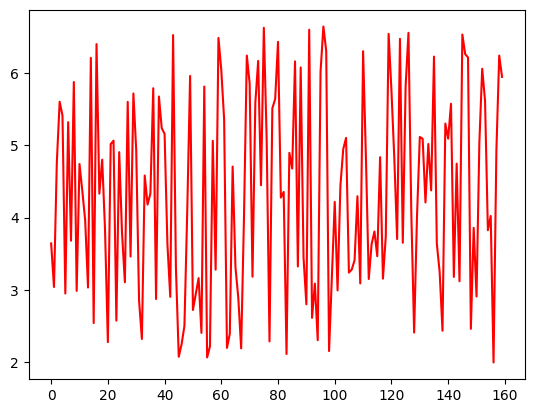

In [25]:
plt.plot(sgd.predict(X_train), color='r')
plt.show()

In [31]:
# applying polynomial regression

poly= PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.fit_transform(X_test)

In [32]:
df  =pd.DataFrame(X_train_trans)
df.head()

,0,1,2
0,1.0,-0.862154,0.743309
1,1.0,-1.637717,2.682116
2,1.0,0.574946,0.330563
3,1.0,1.657834,2.748412
4,1.0,1.411514,1.992371


In [33]:
lr.fit(X_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [34]:
y_pred = lr.predict(X_test_trans)

In [35]:
r2_score(y_test, y_pred)

0.8687243355848251

In [36]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.94701741 0.83033868]]
[1.90582724]


In [37]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

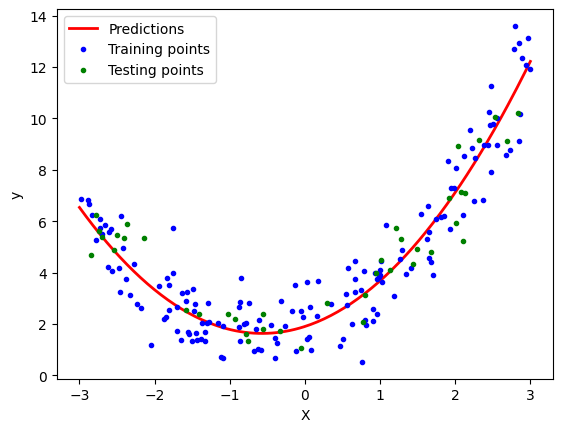

In [38]:
plt.plot(X_new, y_new, 'r-', linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.", label="Training points")
plt.plot(X_test, y_test,"g.", label="Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()